In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

In [4]:
# Activo
ticker = "SPY"

# Descargar información
spy = yf.Ticker(ticker)

# Vencimientos disponibles
expirations = spy.options

print("Vencimientos disponibles:")
print(expirations)

Vencimientos disponibles:
('2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-06-30', '2026-07-17', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [5]:
# Elegimos un vencimiento
expiry = expirations[0]

# Descargar cadena de opciones
chain = spy.option_chain(expiry)

# Calls y puts
calls = chain.calls
puts  = chain.puts

print("CALLS")
display(calls.head())

print("\nPUTS")
display(puts.head())

CALLS


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260511C00500000,2026-05-08 17:05:05+00:00,500.0,237.53,238.73,241.52,0.0,0.0,NaN,NaN,3.844727,True,REGULAR,USD
1,SPY260511C00515000,2026-05-01 16:37:40+00:00,515.0,207.28,223.67,226.44,0.0,0.0,2.0,2.0,3.555665,True,REGULAR,USD
2,SPY260511C00525000,2026-05-01 16:44:26+00:00,525.0,197.29,213.68,216.47,0.0,0.0,4.0,4.0,3.401369,True,REGULAR,USD
3,SPY260511C00600000,2026-05-07 14:49:04+00:00,600.0,135.38,138.70,141.49,0.0,0.0,15.0,15.0,2.239262,True,REGULAR,USD
4,SPY260511C00635000,2026-05-07 16:13:24+00:00,635.0,98.00,103.62,106.42,0.0,0.0,NaN,NaN,1.700197,True,REGULAR,USD



PUTS


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260511P00500000,2026-05-07 18:56:48+00:00,500.0,0.01,0.0,0.01,0.0,0.0,2.0,1013.0,2.187505,False,REGULAR,USD
1,SPY260511P00505000,2026-05-05 13:30:01+00:00,505.0,0.01,NaN,0.01,0.0,0.0,NaN,1.0,2.218754,False,REGULAR,USD
2,SPY260511P00510000,2026-04-29 13:30:01+00:00,510.0,0.02,0.0,0.01,0.0,0.0,NaN,101.0,2.062505,False,REGULAR,USD
3,SPY260511P00515000,2026-04-30 13:42:35+00:00,515.0,0.01,0.0,0.01,0.0,0.0,NaN,1.0,2.000005,False,REGULAR,USD
4,SPY260511P00520000,2026-04-30 15:46:50+00:00,520.0,0.01,0.0,0.01,0.0,0.0,NaN,2.0,1.937500,False,REGULAR,USD


In [6]:
# Precio actual de SPY
S0 = spy.history(period="1d")["Close"].iloc[-1]

print(f"Precio actual de {ticker}: ${S0:.2f}")

Precio actual de SPY: $738.85


In [7]:
# ===== LONG STRADDLE =====
# Strike cercano al precio actual

K_straddle = 740

call_straddle = calls.iloc[(calls['strike'] - K_straddle).abs().argsort()[:1]]
put_straddle  = puts.iloc[(puts['strike'] - K_straddle).abs().argsort()[:1]]

# ===== BULL CALL SPREAD =====

K1 = 735   # call comprada
K2 = 750   # call vendida

call_long  = calls.iloc[(calls['strike'] - K1).abs().argsort()[:1]]
call_short = calls.iloc[(calls['strike'] - K2).abs().argsort()[:1]]

print("Long Straddle")
display(call_straddle)
display(put_straddle)

print("Bull Call Spread")
display(call_long)
display(call_short)

Long Straddle


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
77,SPY260511C00740000,2026-05-11 18:38:37+00:00,740.0,0.51,0.5,0.51,-0.41,-44.56522,634258.0,12647.0,0.061899,False,REGULAR,USD


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
104,SPY260511P00740000,2026-05-11 18:38:36+00:00,740.0,0.38,0.38,0.39,-2.99,-88.72403,486105.0,1428.0,0.00001,True,REGULAR,USD


Bull Call Spread


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
72,SPY260511C00735000,2026-05-11 18:37:14+00:00,735.0,5.07,5.09,5.18,1.4,38.14714,15173.0,4476.0,0.181771,True,REGULAR,USD


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
87,SPY260511C00750000,2026-05-11 18:20:49+00:00,750.0,0.01,0.0,0.01,-0.03,-75.0,4575.0,16384.0,0.115243,False,REGULAR,USD


In [8]:
def payoff_estrategia(S, legs):
    """
    Calcula payoff total de una estrategia de opciones.
    """

    total = np.zeros_like(S)

    for leg in legs:

        K = leg['K']
        prima = leg['prima']
        posicion = leg['posicion']
        tipo = leg['tipo']

        if tipo == 'call':
            payoff = np.maximum(S - K, 0) - prima

        elif tipo == 'put':
            payoff = np.maximum(K - S, 0) - prima

        total += posicion * payoff

    return total

In [9]:
def graficar_estrategia(S_range, pnl, titulo, K_lines=None):

    plt.figure(figsize=(9,5))

    plt.plot(S_range, pnl, linewidth=2)

    plt.axhline(0, color='black', linestyle='--')

    if K_lines:
        for K, label in K_lines:
            plt.axvline(K, linestyle=':', label=label)

    plt.fill_between(S_range, pnl, 0,
                     where=(pnl > 0),
                     alpha=0.15)

    plt.fill_between(S_range, pnl, 0,
                     where=(pnl < 0),
                     alpha=0.15)

    plt.xlabel('$S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

Costo total      : $0.89
Break-even sup.  : $740.89
Break-even inf.  : $739.11
Pérdida máxima   : $-0.89


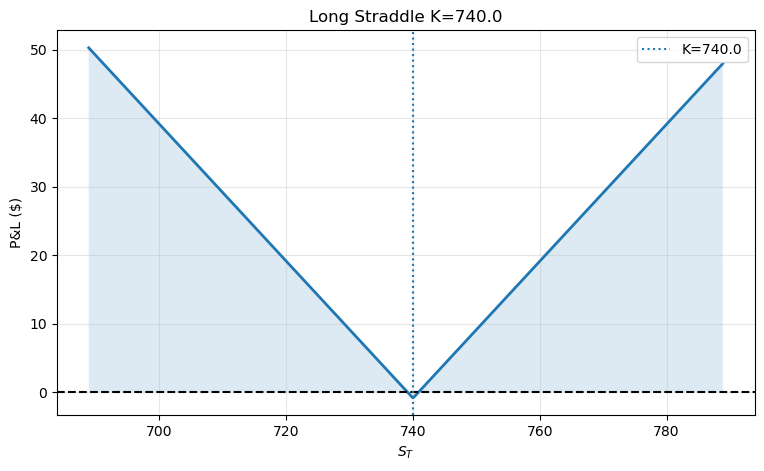

In [10]:
# Datos del straddle

K = float(call_straddle['strike'].iloc[0])

C = float(call_straddle['lastPrice'].iloc[0])
P = float(put_straddle['lastPrice'].iloc[0])

# Rango de precios
S_range = np.linspace(S0 - 50, S0 + 50, 500)

# Estrategia
legs_straddle = [
    {'tipo': 'call', 'K': K, 'prima': C, 'posicion': +1},
    {'tipo': 'put',  'K': K, 'prima': P, 'posicion': +1},
]

# Payoff
pnl_straddle = payoff_estrategia(S_range, legs_straddle)

# Métricas
costo_total = C + P

be_sup = K + costo_total
be_inf = K - costo_total

print(f"Costo total      : ${costo_total:.2f}")
print(f"Break-even sup.  : ${be_sup:.2f}")
print(f"Break-even inf.  : ${be_inf:.2f}")
print(f"Pérdida máxima   : ${-costo_total:.2f}")

# Gráfica
graficar_estrategia(
    S_range,
    pnl_straddle,
    f'Long Straddle K={K}',
    K_lines=[(K, f'K={K}')]
)

Prima neta pagada : $5.06
Ganancia máxima   : $9.94
Pérdida máxima    : $-5.06
Break-even        : $740.06


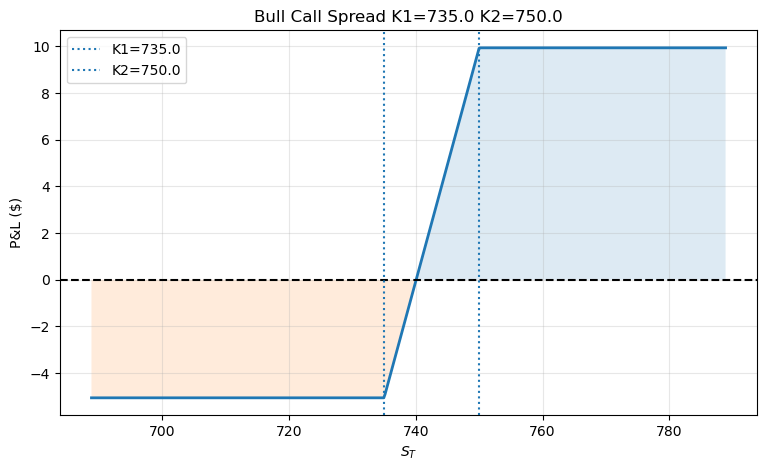

In [11]:
# Datos bull spread

K1 = float(call_long['strike'].iloc[0])
K2 = float(call_short['strike'].iloc[0])

C1 = float(call_long['lastPrice'].iloc[0])
C2 = float(call_short['lastPrice'].iloc[0])

# Estrategia
legs_bull = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -1},
]

# Payoff
pnl_bull = payoff_estrategia(S_range, legs_bull)

# Métricas
prima_neta = C1 - C2

ganancia_max = (K2 - K1) - prima_neta
perdida_max = prima_neta
breakeven = K1 + prima_neta

print(f"Prima neta pagada : ${prima_neta:.2f}")
print(f"Ganancia máxima   : ${ganancia_max:.2f}")
print(f"Pérdida máxima    : ${-perdida_max:.2f}")
print(f"Break-even        : ${breakeven:.2f}")

# Gráfica
graficar_estrategia(
    S_range,
    pnl_bull,
    f'Bull Call Spread K1={K1} K2={K2}',
    K_lines=[(K1, f'K1={K1}'), (K2, f'K2={K2}')]
)

In [12]:
def bs_d1(S, K, r, T, sigma):

    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


def delta_call(S, K, r, T, sigma):

    d1 = bs_d1(S, K, r, T, sigma)

    return norm.cdf(d1)


def delta_put(S, K, r, T, sigma):

    d1 = bs_d1(S, K, r, T, sigma)

    return norm.cdf(d1) - 1


def gamma(S, K, r, T, sigma):

    d1 = bs_d1(S, K, r, T, sigma)

    return norm.pdf(d1) / (S * sigma * np.sqrt(T))


def theta_call(S, K, r, T, sigma):

    d1 = bs_d1(S, K, r, T, sigma)
    d2 = d1 - sigma * np.sqrt(T)

    term1 = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    term2 = -r * K * np.exp(-r * T) * norm.cdf(d2)

    return term1 + term2


def theta_put(S, K, r, T, sigma):

    d1 = bs_d1(S, K, r, T, sigma)
    d2 = d1 - sigma * np.sqrt(T)

    term1 = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    term2 = r * K * np.exp(-r * T) * norm.cdf(-d2)

    return term1 + term2


def vega(S, K, r, T, sigma):

    d1 = bs_d1(S, K, r, T, sigma)

    return S * norm.pdf(d1) * np.sqrt(T)

In [13]:
# Parámetros
r = 0.04
T = 30/365

# Volatilidades implícitas
sigma_call = float(call_straddle['impliedVolatility'].iloc[0])
sigma_put  = float(put_straddle['impliedVolatility'].iloc[0])

# ===== CALL =====

delta_c = delta_call(S0, K, r, T, sigma_call)
gamma_c = gamma(S0, K, r, T, sigma_call)
theta_c = theta_call(S0, K, r, T, sigma_call)
vega_c  = vega(S0, K, r, T, sigma_call)

# ===== PUT =====

delta_p = delta_put(S0, K, r, T, sigma_put)
gamma_p = gamma(S0, K, r, T, sigma_put)
theta_p = theta_put(S0, K, r, T, sigma_put)
vega_p  = vega(S0, K, r, T, sigma_put)

# ===== NETAS =====

delta_net = delta_c + delta_p
gamma_net = gamma_c + gamma_p
theta_net = theta_c + theta_p
vega_net  = vega_c + vega_p

print("=== LONG STRADDLE ===\n")

print("CALL")
print(f"Delta : {delta_c:.4f}")
print(f"Gamma : {gamma_c:.4f}")
print(f"Theta : {theta_c:.4f}")
print(f"Vega  : {vega_c:.4f}\n")

print("PUT")
print(f"Delta : {delta_p:.4f}")
print(f"Gamma : {gamma_p:.4f}")
print(f"Theta : {theta_p:.4f}")
print(f"Vega  : {vega_p:.4f}\n")

print("GRIEGAS NETAS")
print(f"Delta neta : {delta_net:.4f}")
print(f"Gamma neta : {gamma_net:.4f}")
print(f"Theta neta : {theta_net:.4f}")
print(f"Vega neta  : {vega_net:.4f}")

=== LONG STRADDLE ===

CALL
Delta : 0.5426
Gamma : 0.0303
Theta : -47.4385
Vega  : 84.0240

PUT
Delta : 0.0000
Gamma : 0.0000
Theta : 0.0000
Vega  : 0.0000

GRIEGAS NETAS
Delta neta : 0.5426
Gamma neta : 0.0303
Theta neta : -47.4385
Vega neta  : 84.0240


In [14]:
# Volatilidades implícitas
sigma_long  = float(call_long['impliedVolatility'].iloc[0])
sigma_short = float(call_short['impliedVolatility'].iloc[0])

# ===== CALL COMPRADA =====

delta_long = delta_call(S0, K1, r, T, sigma_long)
gamma_long = gamma(S0, K1, r, T, sigma_long)
theta_long = theta_call(S0, K1, r, T, sigma_long)
vega_long  = vega(S0, K1, r, T, sigma_long)

# ===== CALL VENDIDA =====

delta_short = -delta_call(S0, K2, r, T, sigma_short)
gamma_short = -gamma(S0, K2, r, T, sigma_short)
theta_short = -theta_call(S0, K2, r, T, sigma_short)
vega_short  = -vega(S0, K2, r, T, sigma_short)

# ===== NETAS =====

delta_bull = delta_long + delta_short
gamma_bull = gamma_long + gamma_short
theta_bull = theta_long + theta_short
vega_bull  = vega_long + vega_short

print("=== BULL CALL SPREAD ===\n")

print("CALL COMPRADA")
print(f"Delta : {delta_long:.4f}")
print(f"Gamma : {gamma_long:.4f}")
print(f"Theta : {theta_long:.4f}")
print(f"Vega  : {vega_long:.4f}\n")

print("CALL VENDIDA")
print(f"Delta : {delta_short:.4f}")
print(f"Gamma : {gamma_short:.4f}")
print(f"Theta : {theta_short:.4f}")
print(f"Vega  : {vega_short:.4f}\n")

print("GRIEGAS NETAS")
print(f"Delta neta : {delta_bull:.4f}")
print(f"Gamma neta : {gamma_bull:.4f}")
print(f"Theta neta : {theta_bull:.4f}")
print(f"Vega neta  : {vega_bull:.4f}")

=== BULL CALL SPREAD ===

CALL COMPRADA
Delta : 0.5752
Gamma : 0.0102
Theta : -108.0334
Vega  : 83.0010

CALL VENDIDA
Delta : -0.3680
Gamma : -0.0154
Theta : 66.6049
Vega  : -79.8372

GRIEGAS NETAS
Delta neta : 0.2071
Gamma neta : -0.0053
Theta neta : -41.4286
Vega neta  : 3.1638


# Análisis Long Straddle

La estrategia Long Straddle consiste en comprar simultáneamente una call y una put con el mismo strike y vencimiento.

Esta estrategia tiene sentido cuando se espera un movimiento fuerte del mercado, pero no se conoce la dirección exacta. Es una estrategia de compra de volatilidad.

En este caso, la estrategia presenta:

- Vega neta positiva: la posición gana valor si aumenta la volatilidad implícita.
- Theta neta negativa: la estrategia pierde valor con el paso del tiempo si el precio no se mueve significativamente.
- Gamma positiva: movimientos grandes del subyacente benefician la posición.

La pérdida máxima ocurre cuando el precio termina cerca del strike al vencimiento, mientras que la ganancia potencial es ilimitada en ambas direcciones.

# Análisis Bull Call Spread

El Bull Call Spread consiste en comprar una call con strike bajo y vender otra call con strike más alto.

Esta estrategia tiene sentido en un escenario moderadamente alcista, donde se espera que el precio suba, pero no de manera extrema.

Las Griegas netas muestran que:

- Delta neta positiva: la estrategia se beneficia de subidas en el precio del subyacente.
- Vega cercana a cero: la sensibilidad a cambios en volatilidad implícita es reducida porque la call vendida compensa parte de la vega de la call comprada.
- Theta negativa moderada: el paso del tiempo afecta negativamente, aunque menos que comprar una call simple.

La ganancia máxima está limitada por la diferencia entre strikes menos la prima neta pagada, mientras que la pérdida máxima se limita a la prima pagada inicialmente.

# Conclusión

En este ejercicio se descargó una cadena real de opciones usando yfinance y se construyeron dos estrategias con contratos reales de SPY: Long Straddle y Bull Call Spread.

Se analizaron sus diagramas de payoff, puntos de break-even, ganancias y pérdidas máximas, además de calcular las Griegas individuales y netas de cada portafolio mediante Black-Scholes.

El Long Straddle mostró exposición positiva a volatilidad y sensibilidad favorable ante movimientos grandes del mercado, mientras que el Bull Call Spread reflejó una exposición alcista moderada con riesgo limitado y menor sensibilidad a cambios en volatilidad implícita.

Las Griegas permitieron relacionar cuantitativamente cada estrategia con las condiciones de mercado en las que tiene sentido utilizarlas.